In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_recall_curve,
)
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

In [2]:
# ============================================================
# 1. LOAD DATA
# ============================================================

TRAIN_PATH = "data/train.csv"
TEST_PATH = "data/test.csv"
SAMPLE_PATH = "data/sample_submission.csv"

train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)
sub_df = pd.read_csv(SAMPLE_PATH)

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)


Train shape: (15304, 12)
Test shape: (10204, 11)


In [3]:
# ============================================================
# 2. BASIC INSPECTION
# ============================================================

print("\nColumns:")
print(train_df.columns.tolist())

print("\nMissing values:")
print(train_df.isnull().sum())

print("\nDuplicates:", train_df.duplicated().sum())

print("\nTarget distribution:")
print(train_df["stroke"].value_counts())
print(train_df["stroke"].value_counts(normalize=True))



Columns:
['id', 'gender', 'age', 'hypertension', 'heart_disease', 'ever_married', 'work_type', 'Residence_type', 'avg_glucose_level', 'bmi', 'smoking_status', 'stroke']

Missing values:
id                   0
gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
stroke               0
dtype: int64

Duplicates: 0

Target distribution:
stroke
0    14672
1      632
Name: count, dtype: int64
stroke
0    0.958704
1    0.041296
Name: proportion, dtype: float64


In [4]:

# ============================================================
# 3. DATA CLEANING
# ============================================================

# Keep the same cleaning logic as the original project.
# Age is rounded upward to remove fractional age representation.
train_df["age"] = np.ceil(train_df["age"])
test_df["age"] = np.ceil(test_df["age"])

# Remove extremely rare 'Other' gender category for this dataset.
train_df = train_df[train_df["gender"] != "Other"].copy()
test_df = test_df[test_df["gender"] != "Other"].copy()


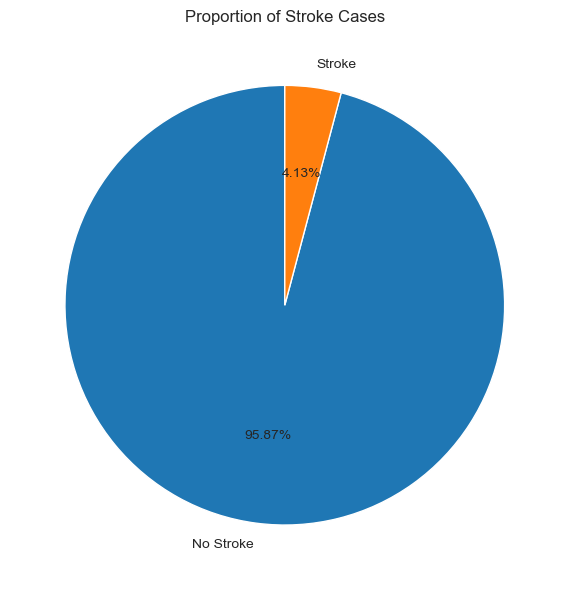

In [5]:
# ============================================================
# 4. EXPLORATORY DATA ANALYSIS
# ============================================================

sns.set_style("darkgrid")

# -----------------------------
# Stroke class distribution
# -----------------------------

stroke_count = train_df["stroke"].value_counts()

plt.figure(figsize=(6, 6))
plt.pie(
    stroke_count.values,
    labels=["No Stroke", "Stroke"],
    autopct="%1.2f%%",
    startangle=90,
)
plt.title("Proportion of Stroke Cases")
plt.tight_layout()
plt.show()



In [6]:

# -----------------------------
# Separate target groups
# -----------------------------

no_stroke_data = train_df[train_df["stroke"] == 0]
stroke_data = train_df[train_df["stroke"] == 1]

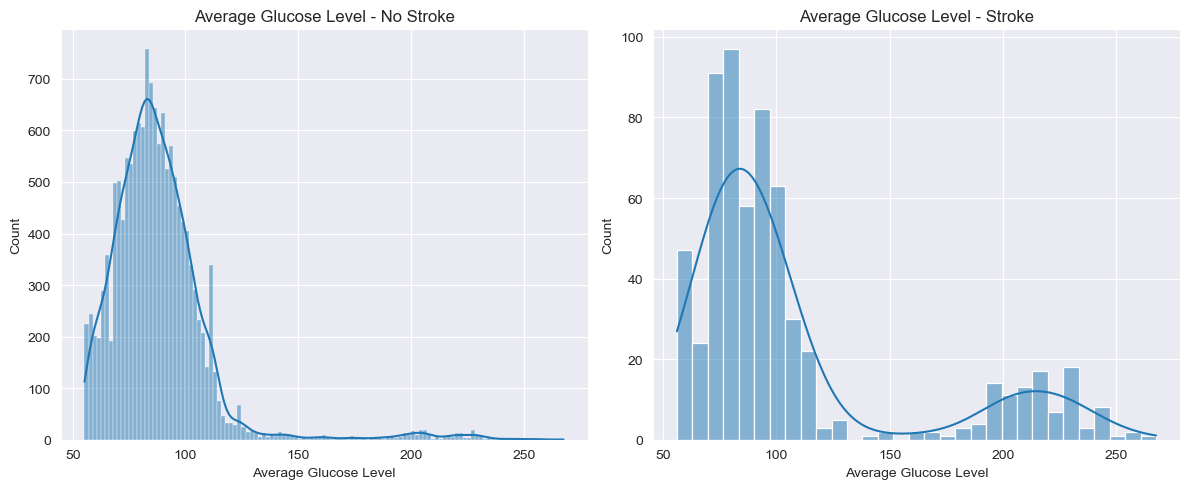

In [7]:
# -----------------------------
# Glucose distribution
# -----------------------------

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(
    no_stroke_data["avg_glucose_level"],
    kde=True,
    ax=axes[0]
)
axes[0].set_title("Average Glucose Level - No Stroke")
axes[0].set_xlabel("Average Glucose Level")

sns.histplot(
    stroke_data["avg_glucose_level"],
    kde=True,
    ax=axes[1]
)
axes[1].set_title("Average Glucose Level - Stroke")
axes[1].set_xlabel("Average Glucose Level")

plt.tight_layout()
plt.show()



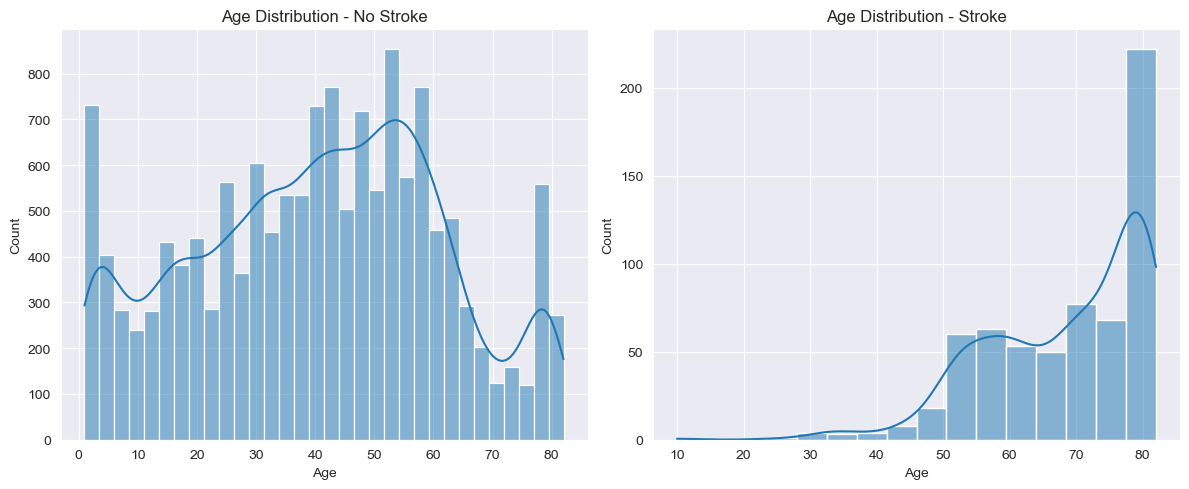

In [8]:
# -----------------------------
# Age distribution
# -----------------------------

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(
    no_stroke_data["age"],
    kde=True,
    ax=axes[0]
)
axes[0].set_title("Age Distribution - No Stroke")
axes[0].set_xlabel("Age")

sns.histplot(
    stroke_data["age"],
    kde=True,
    ax=axes[1]
)
axes[1].set_title("Age Distribution - Stroke")
axes[1].set_xlabel("Age")

plt.tight_layout()
plt.show()



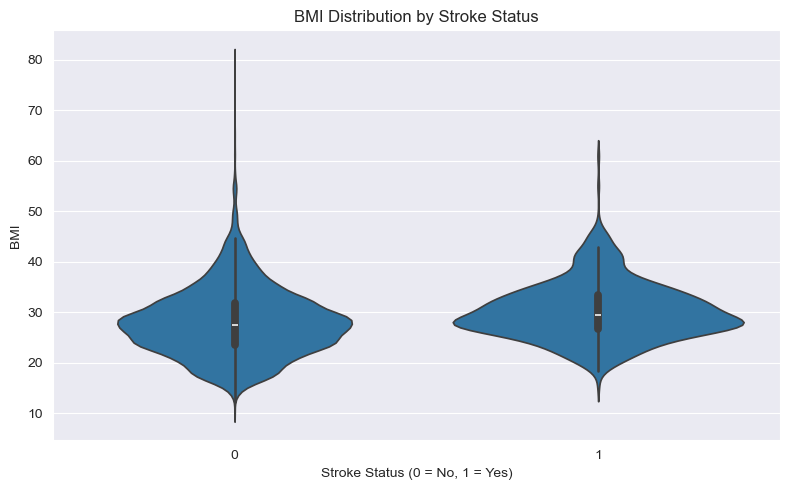

In [9]:

# -----------------------------
# BMI violin plot
# -----------------------------

plt.figure(figsize=(8, 5))
sns.violinplot(
    data=train_df,
    x="stroke",
    y="bmi",
    inner="box"
)
plt.title("BMI Distribution by Stroke Status")
plt.xlabel("Stroke Status (0 = No, 1 = Yes)")
plt.ylabel("BMI")
plt.tight_layout()
plt.show()


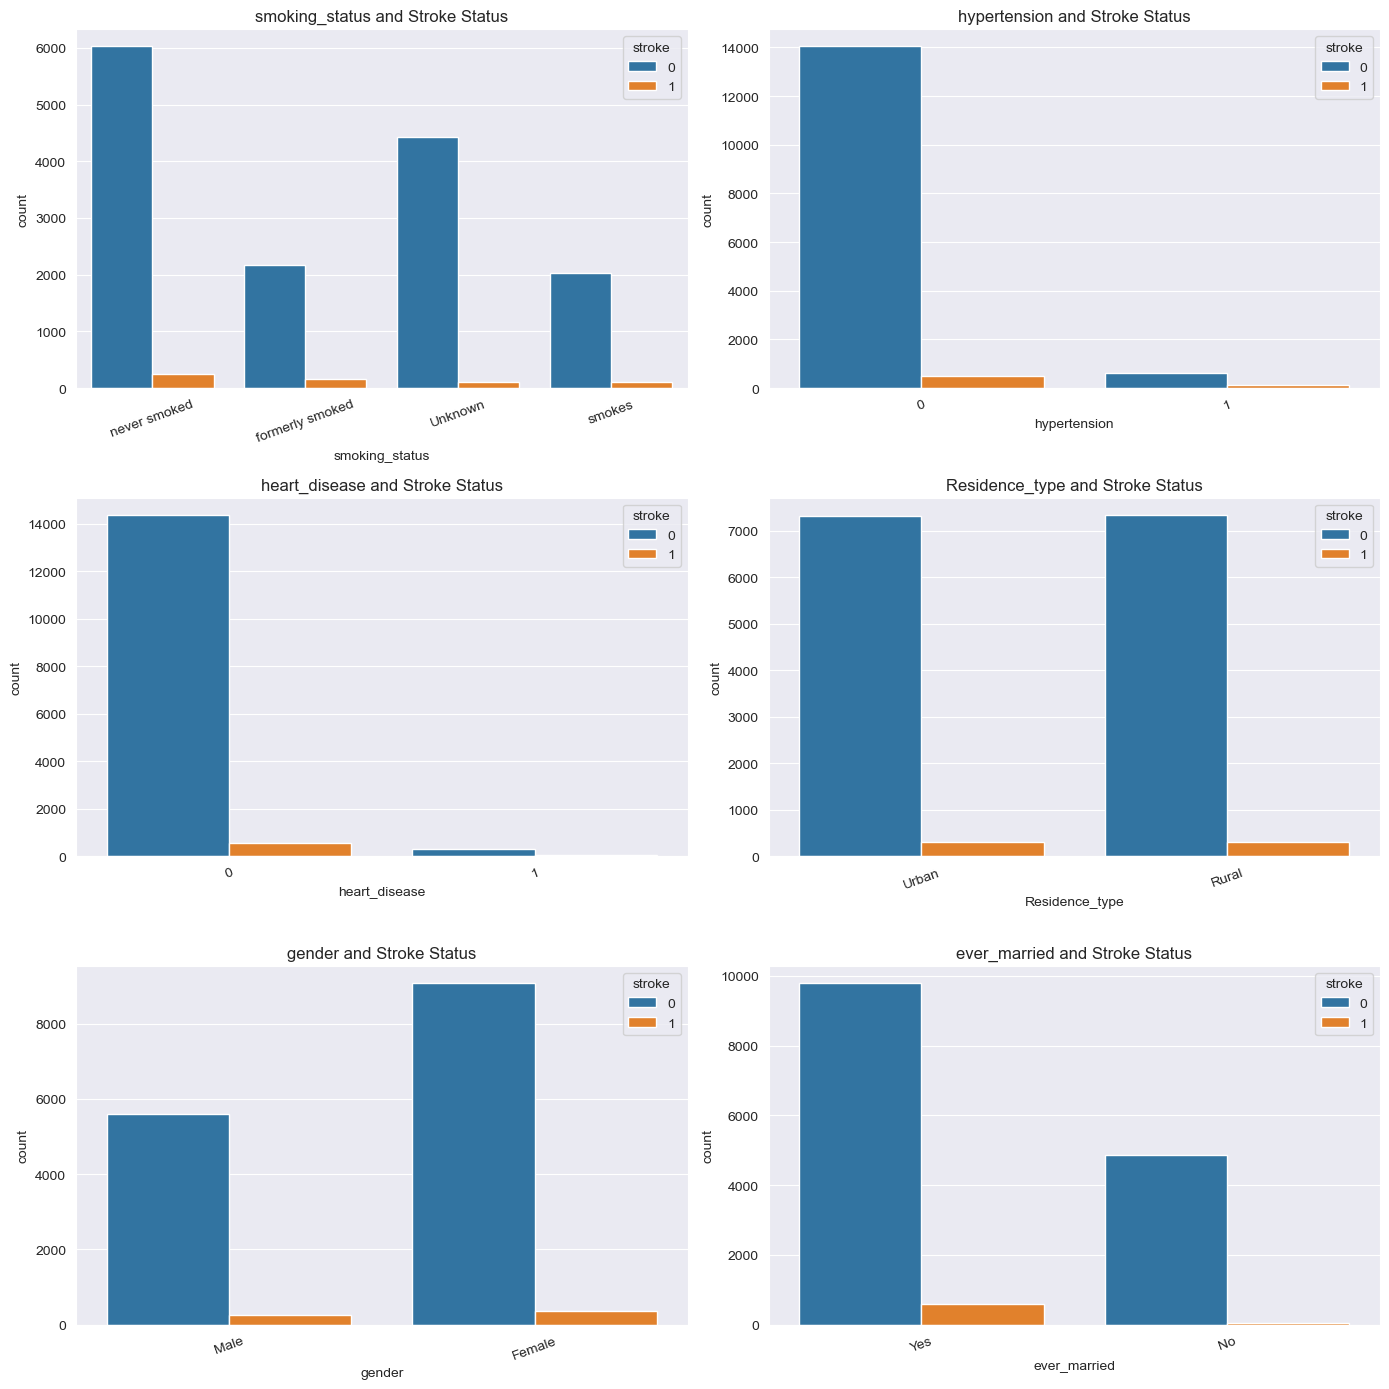

In [10]:

# -----------------------------
# Categorical feature plots
# -----------------------------

categorical_plot_cols = [
    "smoking_status",
    "hypertension",
    "heart_disease",
    "Residence_type",
    "gender",
    "ever_married",
]

fig, axes = plt.subplots(3, 2, figsize=(14, 14))

for ax, col in zip(axes.flat, categorical_plot_cols):
    sns.countplot(
        data=train_df,
        x=col,
        hue="stroke",
        ax=ax
    )
    ax.set_title(f"{col} and Stroke Status")
    ax.tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()


In [11]:

# ============================================================
# 5. FEATURES / TARGET
# ============================================================

input_cols = [
    "gender",
    "age",
    "hypertension",
    "heart_disease",
    "ever_married",
    "work_type",
    "Residence_type",
    "avg_glucose_level",
    "bmi",
    "smoking_status",
]

target_col = "stroke"

X = train_df[input_cols].copy()
y = train_df[target_col].copy()


In [12]:

# ============================================================
# 6. STRATIFIED TRAIN / VALIDATION SPLIT
# ============================================================

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y,
)

print("\nTraining shape:", X_train.shape)
print("Validation shape:", X_val.shape)
print("Training target distribution:")
print(y_train.value_counts())
print("Validation target distribution:")
print(y_val.value_counts())



Training shape: (12242, 10)
Validation shape: (3061, 10)
Training target distribution:
stroke
0    11736
1      506
Name: count, dtype: int64
Validation target distribution:
stroke
0    2935
1     126
Name: count, dtype: int64


In [13]:

# ============================================================
# 7. PREPROCESSING
# ============================================================

numerical_cols = X_train.select_dtypes(include=np.number).columns.tolist()
categorical_cols = X_train.select_dtypes(include="object").columns.tolist()

# Numerical features are scaled for Logistic Regression.
numeric_transformer = Pipeline(
    steps=[
        ("scaler", StandardScaler())
    ]
)

# All categorical features are one-hot encoded.
# This is safer than treating smoking status as inherently ordinal.
categorical_transformer = OneHotEncoder(
    handle_unknown="ignore"
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_cols),
        ("cat", categorical_transformer, categorical_cols),
    ]
)


In [14]:

# ============================================================
# 8. FIT PREPROCESSOR ON TRAINING DATA ONLY
# ============================================================

X_train_processed = preprocessor.fit_transform(X_train)
X_val_processed = preprocessor.transform(X_val)

print("\nProcessed training shape:", X_train_processed.shape)
print("Processed validation shape:", X_val_processed.shape)




Processed training shape: (12242, 20)
Processed validation shape: (3061, 20)


In [15]:

# ============================================================
# 9. APPLY SMOTE ONLY TO TRAINING DATA
# ============================================================

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_processed,
    y_train
)

print("\nBefore SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_smote.value_counts())




Before SMOTE:
stroke
0    11736
1      506
Name: count, dtype: int64

After SMOTE:
stroke
0    11736
1    11736
Name: count, dtype: int64


In [16]:

# ============================================================
# 10. DEFINE MODELS
# ============================================================

models = {
    "Logistic Regression": LogisticRegression(
        max_iter=2000,
        random_state=42,
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1,
    ),

    "XGBoost": XGBClassifier(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1,
    ),

    "LightGBM": LGBMClassifier(
        n_estimators=300,
        learning_rate=0.05,
        num_leaves=31,
        random_state=42,
        verbosity=-1,
    ),
}


In [17]:

# ============================================================
# 11. EVALUATION FUNCTION
# ============================================================

def evaluate_model(model, model_name, Xtr, ytr, Xv, yv):
    model.fit(Xtr, ytr)

    y_pred = model.predict(Xv)
    y_prob = model.predict_proba(Xv)[:, 1]

    cm = confusion_matrix(yv, y_pred)

    result = {
        "Model": model_name,
        "Accuracy": accuracy_score(yv, y_pred),
        "Precision": precision_score(yv, y_pred, zero_division=0),
        "Recall": recall_score(yv, y_pred, zero_division=0),
        "F1": f1_score(yv, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(yv, y_prob),
        "PR-AUC": average_precision_score(yv, y_prob),
        "TN": cm[0, 0],
        "FP": cm[0, 1],
        "FN": cm[1, 0],
        "TP": cm[1, 1],
    }

    return result, model



In [18]:

# ============================================================
# 12. BASELINE + SMOTE MODEL COMPARISON
# ============================================================

results = []
trained_models = {}

# Baseline models
for name, model in models.items():
    result, fitted_model = evaluate_model(
        model,
        name,
        X_train_processed,
        y_train,
        X_val_processed,
        y_val,
    )

    results.append(result)
    trained_models[name] = fitted_model


# SMOTE models
for name, model in models.items():
    # Create a fresh model so it is independently trained.
    if name == "Logistic Regression":
        smote_model = LogisticRegression(
            max_iter=2000,
            random_state=42,
        )
    elif name == "Random Forest":
        smote_model = RandomForestClassifier(
            n_estimators=300,
            random_state=42,
            n_jobs=-1,
        )
    elif name == "XGBoost":
        smote_model = XGBClassifier(
            n_estimators=300,
            max_depth=4,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            eval_metric="logloss",
            random_state=42,
            n_jobs=-1,
        )
    else:
        smote_model = LGBMClassifier(
            n_estimators=300,
            learning_rate=0.05,
            num_leaves=31,
            random_state=42,
            verbosity=-1,
        )

    result, fitted_model = evaluate_model(
        smote_model,
        name + " + SMOTE",
        X_train_smote,
        y_train_smote,
        X_val_processed,
        y_val,
    )

    results.append(result)
    trained_models[name + " + SMOTE"] = fitted_model


results_df = pd.DataFrame(results)
results_df = results_df.sort_values(
    by=["Recall", "F1"],
    ascending=[False, False]
).reset_index(drop=True)

print("\n================ MODEL COMPARISON ================")
print(
    results_df[
        [
            "Model",
            "Accuracy",
            "Precision",
            "Recall",
            "F1",
            "ROC-AUC",
            "PR-AUC",
        ]
    ].to_string(index=False)
)

results_df.to_csv("model_comparison.csv", index=False)


================ MODEL COMPARISON ================
                      Model  Accuracy  Precision   Recall       F1  ROC-AUC   PR-AUC
Logistic Regression + SMOTE  0.791245   0.145228 0.833333 0.247350 0.897994 0.306854
            XGBoost + SMOTE  0.886638   0.190476 0.539683 0.281573 0.871671 0.199242
           LightGBM + SMOTE  0.932702   0.253086 0.325397 0.284722 0.869238 0.201632
      Random Forest + SMOTE  0.914734   0.177033 0.293651 0.220896 0.861580 0.170809
                   LightGBM  0.957857   0.444444 0.095238 0.156863 0.892758 0.280086
                    XGBoost  0.958510   0.478261 0.087302 0.147651 0.897134 0.295118
              Random Forest  0.958510   0.473684 0.071429 0.124138 0.871431 0.239873
        Logistic Regression  0.959164   0.600000 0.023810 0.045802 0.898580 0.326170


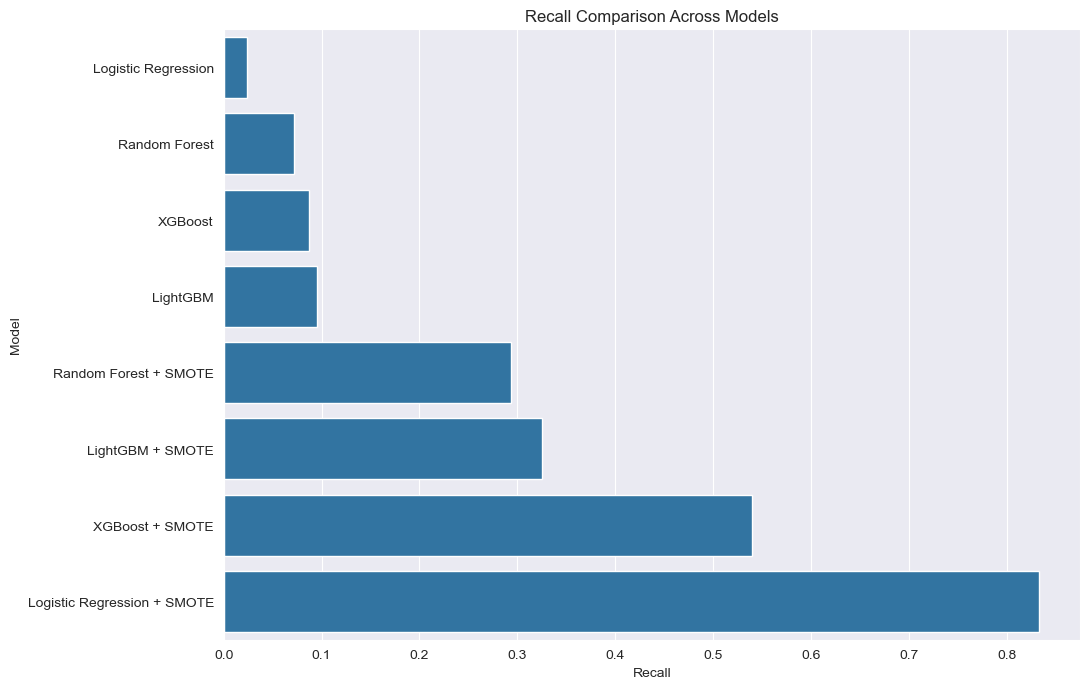

In [19]:

# ============================================================
# 13. RECALL COMPARISON PLOT
# ============================================================

plot_df = results_df.sort_values("Recall", ascending=True)

plt.figure(figsize=(11, 7))
sns.barplot(
    data=plot_df,
    x="Recall",
    y="Model"
)
plt.title("Recall Comparison Across Models")
plt.xlabel("Recall")
plt.ylabel("Model")
plt.tight_layout()
plt.show()


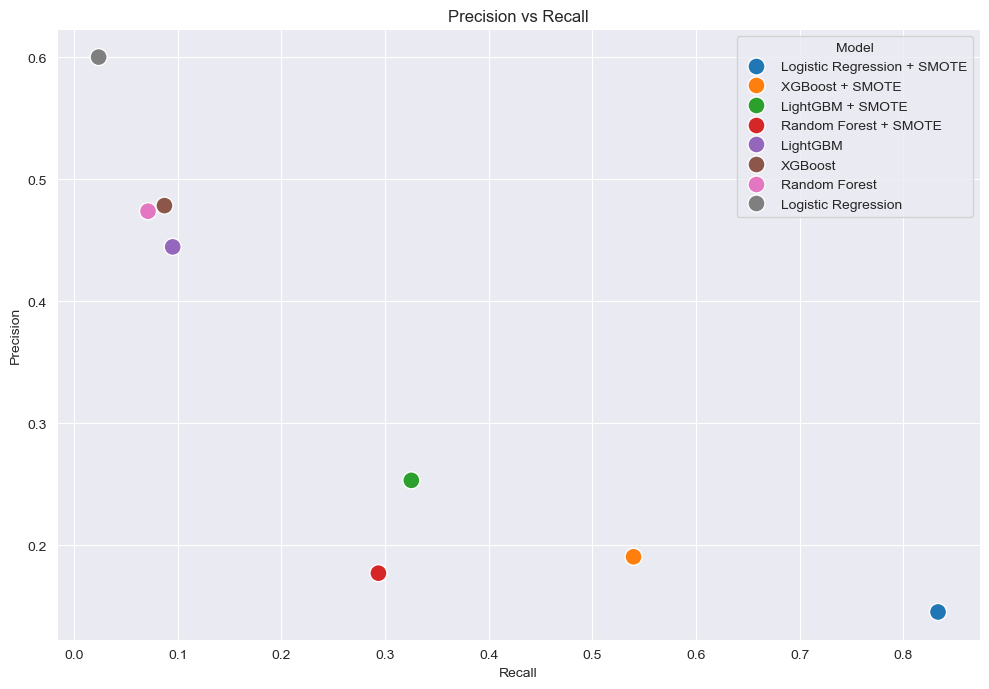

In [20]:

# ============================================================
# 14. PRECISION VS RECALL PLOT
# ============================================================

plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=results_df,
    x="Recall",
    y="Precision",
    hue="Model",
    s=150
)
plt.title("Precision vs Recall")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.tight_layout()
plt.show()


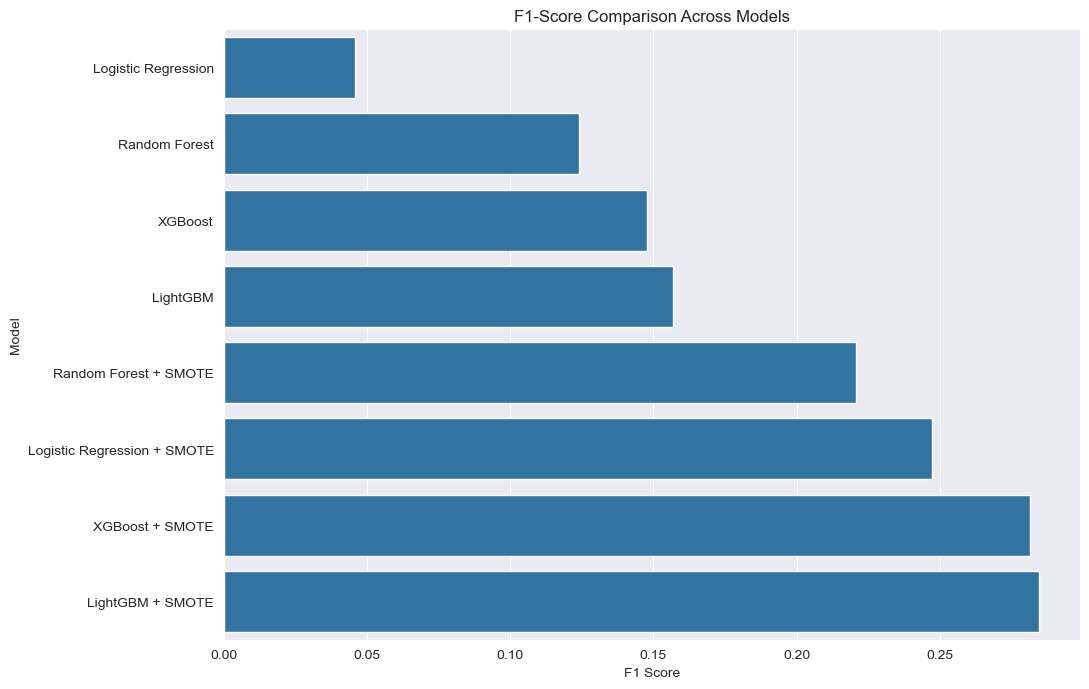

In [21]:

# ============================================================
# 15. F1 COMPARISON
# ============================================================

plot_df = results_df.sort_values("F1", ascending=True)

plt.figure(figsize=(11, 7))
sns.barplot(
    data=plot_df,
    x="F1",
    y="Model"
)
plt.title("F1-Score Comparison Across Models")
plt.xlabel("F1 Score")
plt.ylabel("Model")
plt.tight_layout()
plt.show()


In [22]:

# ============================================================
# 16. SELECT RECALL-ORIENTED CANDIDATE
# ============================================================

# IMPORTANT:
# This selection is based on the models actually evaluated.
# The candidate with the highest recall is selected first.

best_row = results_df.iloc[0]
best_name = best_row["Model"]

print("\nRecall-oriented candidate:", best_name)
print(best_row)


Recall-oriented candidate: Logistic Regression + SMOTE
Model        Logistic Regression + SMOTE
Accuracy                        0.791245
Precision                       0.145228
Recall                          0.833333
F1                               0.24735
ROC-AUC                         0.897994
PR-AUC                          0.306854
TN                                  2317
FP                                   618
FN                                    21
TP                                   105
Name: 0, dtype: object


In [23]:

# ============================================================
# 17. THRESHOLD ANALYSIS FOR LR + SMOTE
# ============================================================

# We specifically analyze LR + SMOTE because it is the model used
# by the Flask application in this project version.

lr_smote = trained_models["Logistic Regression + SMOTE"]

lr_prob = lr_smote.predict_proba(X_val_processed)[:, 1]

threshold_rows = []

for threshold in np.arange(0.10, 0.71, 0.05):
    y_threshold_pred = (lr_prob >= threshold).astype(int)

    threshold_rows.append({
        "Threshold": round(float(threshold), 2),
        "Precision": precision_score(
            y_val,
            y_threshold_pred,
            zero_division=0,
        ),
        "Recall": recall_score(
            y_val,
            y_threshold_pred,
            zero_division=0,
        ),
        "F1": f1_score(
            y_val,
            y_threshold_pred,
            zero_division=0,
        ),
    })

threshold_df = pd.DataFrame(threshold_rows)

print("\n================ THRESHOLD ANALYSIS ================")
print(threshold_df.to_string(index=False))

threshold_df.to_csv("threshold_analysis.csv", index=False)


================ THRESHOLD ANALYSIS ================
 Threshold  Precision   Recall       F1
      0.10   0.071672 1.000000 0.133758
      0.15   0.082085 1.000000 0.151716
      0.20   0.090058 0.992063 0.165125
      0.25   0.097233 0.976190 0.176851
      0.30   0.104386 0.944444 0.187994
      0.35   0.112524 0.912698 0.200348
      0.40   0.122004 0.888889 0.214559
      0.45   0.134058 0.880952 0.232704
      0.50   0.145228 0.833333 0.247350
      0.55   0.156894 0.785714 0.261559
      0.60   0.170686 0.730159 0.276692
      0.65   0.185804 0.706349 0.294215
      0.70   0.206311 0.674603 0.315985


In [24]:
best_threshold = threshold_df.loc[
    threshold_df["F1"].idxmax(), "Threshold"
]

print("Selected threshold:", best_threshold)

Selected threshold: 0.7



Logistic Regression + SMOTE confusion matrix at threshold 0.7:
[[2608  327]
 [  41   85]]


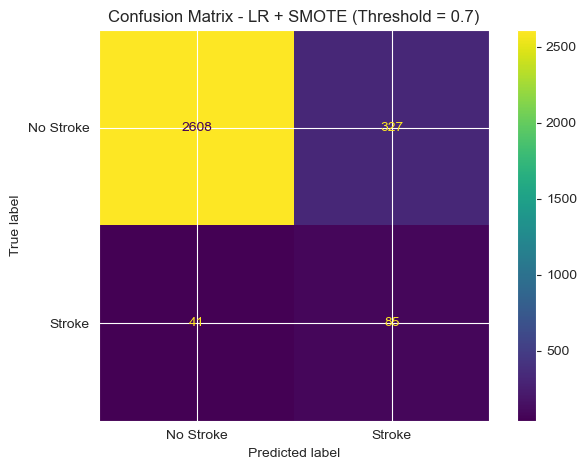

In [25]:
# ============================================================
# 18. CONFUSION MATRIX FOR LR + SMOTE AT SELECTED THRESHOLD
# ============================================================

selected_threshold = 0.70

lr_pred = (lr_prob >= selected_threshold).astype(int)
lr_cm = confusion_matrix(y_val, lr_pred)

print(f"\nLogistic Regression + SMOTE confusion matrix at threshold {selected_threshold}:")
print(lr_cm)

ConfusionMatrixDisplay(
    confusion_matrix=lr_cm,
    display_labels=["No Stroke", "Stroke"]
).plot()

plt.title(
    f"Confusion Matrix - LR + SMOTE (Threshold = {selected_threshold})"
)
plt.tight_layout()
plt.show()

In [27]:
# ============================================================
# 19. FINAL MODEL: LR + SMOTE
# ============================================================

# Logistic Regression + SMOTE was selected because it achieved
# the highest recall among the evaluated models.
#
# Threshold analysis was then performed to improve the
# precision-recall trade-off. The selected operating threshold
# is 0.70 because it gave the highest F1-score among the
# tested thresholds.

selected_threshold = 0.70

final_pipeline = ImbPipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("smote", SMOTE(random_state=42)),
        (
            "model",
            LogisticRegression(
                max_iter=2000,
                random_state=42,
            ),
        ),
    ]
)

# Train final pipeline on all available labeled data
final_pipeline.fit(X, y)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'hypertension',
                                                   'heart_disease',
                                                   'avg_glucose_level',
                                                   'bmi']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['gender', 'ever_married',
                                                   'work_type',
                                                   'Residence_type',
                                                   'smoking_status'])])),
                ('smote', SMOTE(random_state=42)),
                ('model', LogisticRegression(max_iter=2000, random_state=42))])

In [29]:
# ============================================================
# 20. TEST PREDICTIONS / SUBMISSION
# ============================================================

# Reload ORIGINAL test data so that no test rows are removed
test_original = pd.read_csv("data/test.csv")

# Apply only the same valid feature transformation
test_original["age"] = np.ceil(test_original["age"])

test_inputs = test_original[input_cols].copy()

# Get probability of stroke
test_probabilities = final_pipeline.predict_proba(test_inputs)[:, 1]

# Apply selected threshold
test_predictions = (
    test_probabilities >= selected_threshold
).astype(int)

print("Number of test rows:", len(test_inputs))
print("Number of predictions:", len(test_predictions))

# Create submission
if isinstance(sub_df, pd.DataFrame) and len(sub_df) == len(test_predictions):
    submission = sub_df.copy()
    submission[submission.columns[-1]] = test_predictions
else:
    submission = pd.DataFrame({
        "stroke": test_predictions
    })

submission.to_csv("submission.csv", index=False)

print("\nSubmission saved to submission.csv")
print(submission.head())
print("Submission shape:", submission.shape)

Number of test rows: 10204
Number of predictions: 10204

Submission saved to submission.csv
      id  stroke
0  15304       0
1  15305       1
2  15306       0
3  15307       0
4  15308       0
Submission shape: (10204, 2)


In [30]:
# ============================================================
# 21. SAVE FINAL PIPELINE
# ============================================================

joblib.dump(
    final_pipeline,
    "stroke_prediction_pipeline.joblib"
)

print("\nFinal pipeline saved as stroke_prediction_pipeline.joblib")
print("Training complete.")


Final pipeline saved as stroke_prediction_pipeline.joblib
Training complete.
